In [33]:
import numpy as np
import librosa as lb
import HMMOLTW
from pathlib import Path
import numpy as np
import importlib
import IterativeTrainHMM
import matplotlib.pyplot as plt
import Constants
from scipy.special import logsumexp

importlib.reload(IterativeTrainHMM)
importlib.reload(HMMOLTW)

<module 'HMMOLTW' from 'c:\\Users\\morgp\\Documents\\.HMC\\.Year 3\\E207\\Python\\Project\\E207DTWHMM\\HMMOLTW.py'>

In [23]:
A = np.random.rand(5,5)
print(A)
B = np.max(A, axis = 0)
print(B)

[[0.22567713 0.56480998 0.64424205 0.75903882 0.22934333]
 [0.0135533  0.13582831 0.87967952 0.2952651  0.96058054]
 [0.37741336 0.31622856 0.80020297 0.48129298 0.20015067]
 [0.82429262 0.81791955 0.40910221 0.39282793 0.65381999]
 [0.72191172 0.18459527 0.32542138 0.93590732 0.15845101]]
[0.82429262 0.81791955 0.87967952 0.93590732 0.96058054]


In [4]:
PIECE_ID = "Chopin_Op030No2"
DATA_DIR = Path("data/wav_22050_mono") / PIECE_ID
TRAIN_FRACTION = 0.70
TEST_RECORDING_COUNT = 3

recording_paths = sorted(DATA_DIR.glob("*.wav"))
reference_path = recording_paths[0]

rng = np.random.default_rng(207)
query_pool = np.array(recording_paths[1:], dtype=object)
shuffled_pool = query_pool[rng.permutation(len(query_pool))]
train_count = int(np.ceil(TRAIN_FRACTION * len(recording_paths))) - 1
train_paths = sorted(shuffled_pool[:train_count])
heldout_paths = sorted(shuffled_pool[train_count:])
test_paths = heldout_paths[:TEST_RECORDING_COUNT]

print(f"reference: {reference_path.name}")
print(f"total recordings: {len(recording_paths)}")
print(f"training recordings: {1 + len(train_paths)} including the reference ({(1 + len(train_paths)) / len(recording_paths):.1%})")
print(f"held-out recordings: {len(heldout_paths)}")
print("test queries:")
for path in test_paths:
    print(f"  {path.name}")

reference: Chopin_Op030No2_Ashkenazy-1981_pid9058-19.wav
total recordings: 34
training recordings: 24 including the reference (70.6%)
held-out recordings: 10
test queries:
  Chopin_Op030No2_Chiu-1999_pid9048-19.wav
  Chopin_Op030No2_Cortot-1951_pid9066-19.wav
  Chopin_Op030No2_Fiorentino-1961_pid9065-14.wav


In [5]:
A, Pi, Means, Covars = IterativeTrainHMM.Exec_IterativeTrainHMM(
    str(reference_path),
    [str(path) for path in train_paths],
)

print(f"transition matrix: {A.shape}")
print(f"initial distribution: {Pi.shape}")
print(f"emission states: {len(Means)}")
print(f"feature dim: {Means[0].shape[0]}")

transition matrix: (2990, 2990)
initial distribution: (2990,)
emission states: 2990
feature dim: 12


In [6]:
QueryAudio, QuerySampleRate = lb.load("data/wav_22050_mono/Chopin_Op024No2/Chopin_Op024No2_Rubinstein-1966_pid9059-15.wav") 
ReferenceAudio, ReferenceSampleRate = lb.load(reference_path) 

QueryChroma = lb.feature.chroma_stft(y = QueryAudio, sr = QuerySampleRate, hop_length = Constants.DEFAULT_HOP_SIZE_SAMPLES)
ReferenceChroma = lb.feature.chroma_stft(y = ReferenceAudio, sr = ReferenceSampleRate, hop_length = Constants.DEFAULT_HOP_SIZE_SAMPLES)

HMM, ViterbiState, DTWState = HMMOLTW.InitializeHMMStreamingDTW(ReferenceChroma, A, Pi, Means, Covars)
SearchHalfWidth = 500
HMMWeight = 1
Estimates = []

ReferenceFrameCount = ReferenceChroma.shape[1]

LibrosaProbMatrix = np.zeros((ReferenceFrameCount, ReferenceFrameCount))

for QueryFeatureIndex in range(QueryChroma.shape[1]):

    QueryRow = QueryChroma[:, QueryFeatureIndex]

    WeightedMidpointState, ViterbiState, DTWState = HMMOLTW.ProcessNextFrame(
        ViterbiState, 
        DTWState,
        HMM,
        ReferenceChroma,
        QueryRow,
        SearchHalfWidth,
        HMMWeight)
    
    Estimates.append(WeightedMidpointState)

    LogEmissions = np.array([
        HMMOLTW.ComputeLogGaussianEmission(
            QueryRow,
            HMM.Means[StateIndex],
            HMM.CovarianceInverses[StateIndex],
            HMM.LogCovarianceDeterminants[StateIndex]
        )
        for StateIndex in range(ReferenceFrameCount)
    ])

    LibrosaProbMatrix[:, QueryFeatureIndex] = LogEmissions


QueryPath = np.arange(len(Estimates))


c:\Users\morgp\Documents\.HMC\.Year 3\E207\Python\Project\E207DTWHMM\HMMOLTW.py:121: RuntimeWarning: divide by zero encountered in log
  LogTransitionMatrix = np.where(TransitionMatrix > 0, np.log(TransitionMatrix), -np.inf)
c:\Users\morgp\Documents\.HMC\.Year 3\E207\Python\Project\E207DTWHMM\HMMOLTW.py:155: RuntimeWarning: divide by zero encountered in log
  LogPi = np.where(PiFlat > 0, np.log(PiFlat), -np.inf)


KeyboardInterrupt: 

[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 9, 9, 9, 9, 9, 9, 10, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

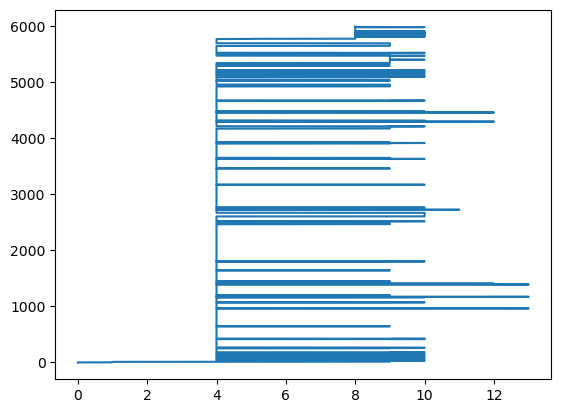

In [ ]:
plt.plot(Estimates, QueryPath)

In [9]:
C = np.copy(B)
C[-1] = -np.inf
np.isfinite(C)

array([ True,  True,  True,  True, False])

In [ ]:
TestFrom = np.array([1, 2, 3])
TestTo = np.array([2, 3, 4])

D = np.ix_(TestFrom, TestTo)
print(A)
print(A[D])

[[0.22567713 0.56480998 0.64424205 0.75903882 0.22934333]
 [0.0135533  0.13582831 0.87967952 0.2952651  0.96058054]
 [0.37741336 0.31622856 0.80020297 0.48129298 0.20015067]
 [0.82429262 0.81791955 0.40910221 0.39282793 0.65381999]
 [0.72191172 0.18459527 0.32542138 0.93590732 0.15845101]]
[[0.87967952 0.2952651  0.96058054]
 [0.80020297 0.48129298 0.20015067]
 [0.40910221 0.39282793 0.65381999]]


In [32]:
print(B)
print(A)

B[:, np.newaxis] + A

[0.82429262 0.81791955 0.87967952 0.93590732 0.96058054]
[[0.22567713 0.56480998 0.64424205 0.75903882 0.22934333]
 [0.0135533  0.13582831 0.87967952 0.2952651  0.96058054]
 [0.37741336 0.31622856 0.80020297 0.48129298 0.20015067]
 [0.82429262 0.81791955 0.40910221 0.39282793 0.65381999]
 [0.72191172 0.18459527 0.32542138 0.93590732 0.15845101]]


array([[1.04996975, 1.3891026 , 1.46853466, 1.58333144, 1.05363594],
       [0.83147285, 0.95374786, 1.69759907, 1.11318465, 1.77850009],
       [1.25709288, 1.19590808, 1.67988249, 1.3609725 , 1.07983019],
       [1.76019994, 1.75382687, 1.34500953, 1.32873525, 1.58972732],
       [1.68249226, 1.14517581, 1.28600192, 1.89648787, 1.11903155]])

In [36]:
E = np.full(5, -np.inf)
E[3] = 4

print(logsumexp(E))

4.0
